In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv(r"C:\Users\xys\Downloads\world_happiness_2023.csv")
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']

print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

import plotly.express as px
import plotly.graph_objects as go

Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [2]:
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

                         Region  Happiness_Score
8                Western Europe         7.085533
4         North America and ANZ         7.018250
0    Central and Eastern Europe         6.338143
1                     East Asia         5.966000
2   Latin America and Caribbean         5.699000
6                Southeast Asia         5.695250
3  Middle East and North Africa         4.943333
7            Sub-Saharan Africa         4.064714
5                    South Asia         3.618250


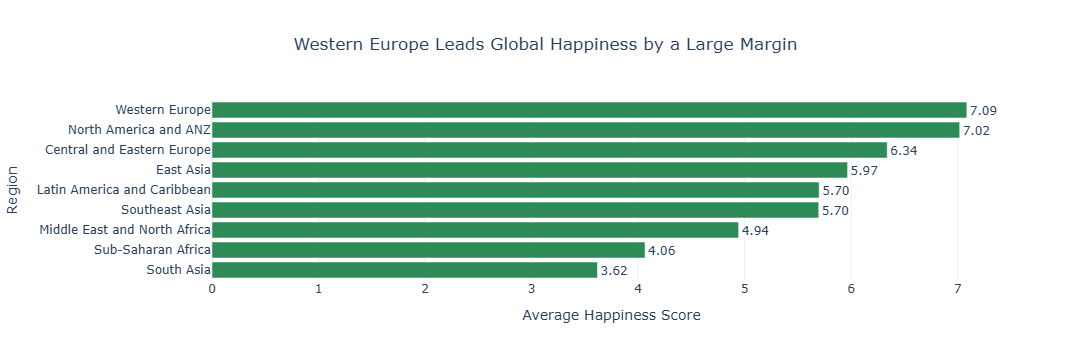

In [4]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score', ascending=False))  

print(region_avg)

# Step 2: Build your chart
fig = px.bar(
    region_avg,
    x="Happiness_Score",
    y="Region",
    orientation="h", 
    title="Western Europe Leads Global Happiness by a Large Margin",
    color_discrete_sequence=["#2E8B57"]  
)


fig.update_layout(
    xaxis_range=[0, 7.5], 
    yaxis_categoryorder="total ascending",  
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Average Happiness Score",
    yaxis_title="Region"
)


fig.update_traces(texttemplate="%{x:.2f}", textposition="outside")

fig.show()

Global average: 5.81


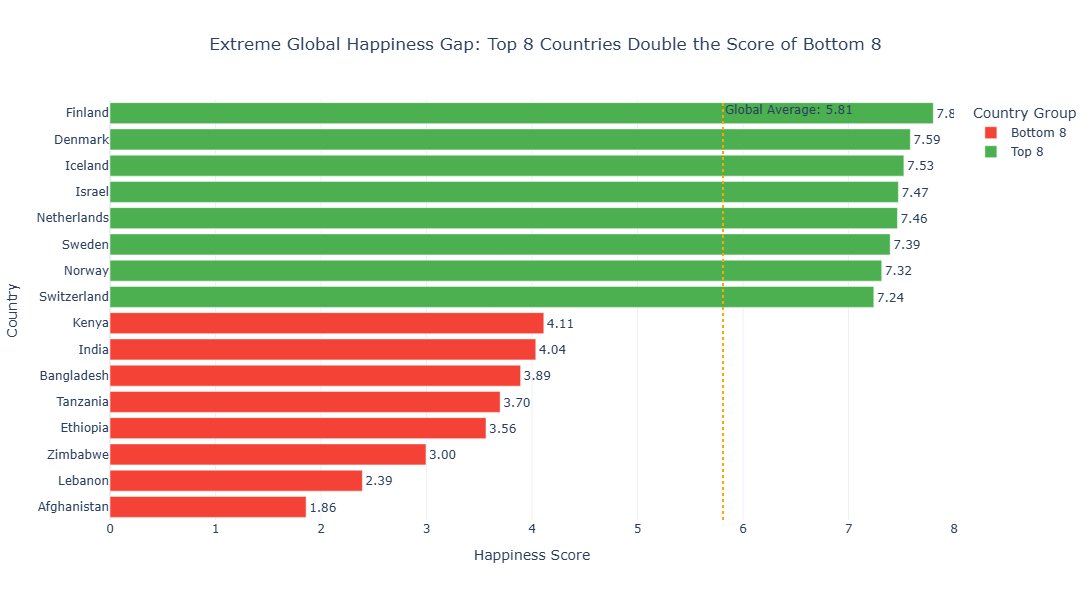

In [5]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries 
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build your chart 
import plotly.express as px

fig = px.bar(
    combined,
    x="Happiness_Score",
    y="Country",
    orientation="h", 
    color="Group",  
    color_discrete_map={  
        "Top 8": "#4CAF50",   
        "Bottom 8": "#F44336"
    },
    
    title="Extreme Global Happiness Gap: Top 8 Countries Double the Score of Bottom 8",
    labels={"Happiness_Score": "Happiness Score", "Country": "Country"}
)


fig.update_layout(
    xaxis_range=[0, 8], 
    template="plotly_white",
    title_x=0.5,
    height=600, 
    legend_title="Country Group"
)

fig.add_vline(
    x=global_avg,
    line_dash="dot",
    line_color="orange",
    line_width=2,
    annotation_text=f"Global Average: {global_avg:.2f}",
    annotation_position="top right"
)


fig.update_traces(texttemplate="%{x:.2f}", textposition="outside")
fig.show()

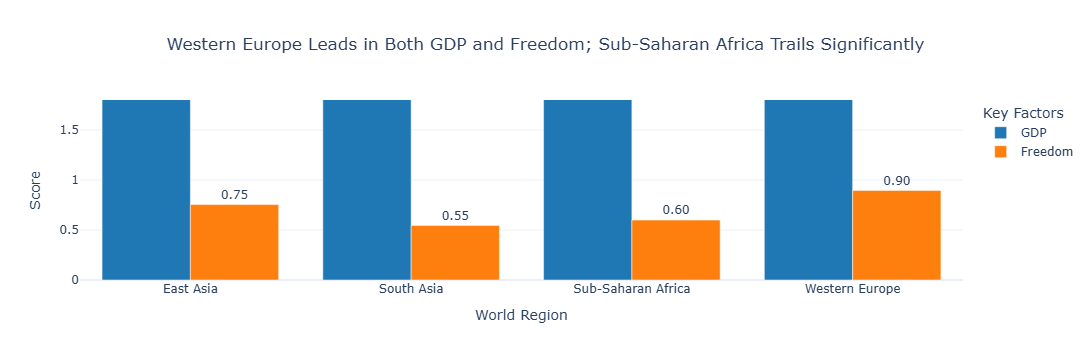

In [6]:
# Task 3: Grouped Bar Chart - GDP & Freedom Across Top 5 Populated Regions
# -------------------------------------------------------------------------

# Step 1: 
target_regions = [
    'Western Europe', 
    'Latin America', 
    'East Asia', 
    'Sub-Saharan Africa', 
    'South Asia'
]
region_filtered = df[df['Region'].isin(target_regions)]

# Step 2: 
factor_avg = region_filtered.groupby('Region')[['GDP', 'Freedom']].mean().reset_index()

# Step 3: 
fig = px.bar(
    factor_avg,
    x='Region',
    y=['GDP', 'Freedom'], 
    barmode='group',       
    title='Western Europe Leads in Both GDP and Freedom; Sub-Saharan Africa Trails Significantly',
    color_discrete_map={   
        'GDP': '#1f77b4',
        'Freedom': '#ff7f0e'
    },
    labels={
        'value': 'Score',
        'variable': 'Metric',
        'Region': 'World Region'
    }
)


fig.update_layout(
    yaxis_range=[0, 1.8],    
    template='plotly_white',
    title_x=0.5,
    legend_title='Key Factors'
)

fig.update_traces(texttemplate='%{y:.2f}', textposition='outside')
fig.show()